In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy
from sklearn import metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split 
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression


## Data analysis

In [2]:
# train2.csv: stacked train+test passenger rows without Survived (labels added in making_submission_file.ipynb)
df = pd.read_csv('train2.csv')

df['Embarked'] = df['Embarked'].fillna('S')
df['Title'] = df['Name'].str.extract(r',\s*([^\.]*)\.', expand=False)
title_mapping = {
    'Mr': 'Mr',
    'Mrs': 'Mrs',
    'Miss': 'Miss',
    'Master': 'Master',
    'Mlle': 'Miss',     # French for Miss
    'Ms': 'Miss',
    'Mme': 'Mrs',       # French for Mrs
    'Lady': 'Mrs',
    'Countess': 'Mrs',
    'Dona': 'Mrs',
    'Sir': 'Mr',
    'Jonkheer': 'Mr',
    'Don': 'Mr',
    'Rev': 'Mr',
    'Dr': 'Mr',
    'Col': 'Mr',
    'Major': 'Mr',
    'Capt': 'Mr'
}
df['Title'] = df['Title'].map(title_mapping).fillna('Mrs') #I use "mrs" because it yielded a greater accuracy percantage in kaggle
df['Deck'] = df['Cabin'].str[0]
df['Deck'] = df['Deck'].replace('T', 'U')
df['Deck'] = df['Deck'].fillna('U')
df = df.drop(['Cabin'], axis=1)
# Fare can be missing in merged train+test; regressors need finite numeric inputs
df['Fare'] = df.groupby('Pclass')['Fare'].transform(lambda s: s.fillna(s.median()))
df['Fare'] = df['Fare'].fillna(df['Fare'].median())


### making two tables one where the age is known and the other where the age is unknown, this is so i can first predict the age of the unknowns before predicting survival rate. I needed to eliminate the blanks in the age column

In [3]:
known_age = df[df['Age'].notnull()]
y_known = known_age['Age']
known_age = known_age.drop(columns=['Name', 'Age'])
unknown_age = df[df['Age'].isnull()]
unknown_age = unknown_age.drop(columns=['Name', 'Age'])
print(known_age.shape)
print(unknown_age.shape)
known_age.head()

(1046, 10)
(263, 10)


,PassengerId,Pclass,Sex,SibSp,Parch,Ticket,Fare,Embarked,Title,Deck
0,1,3,male,1,0,A/5 21171,7.2500,S,Mr,U
1,2,1,female,1,0,PC 17599,71.2833,C,Mrs,C
2,3,3,female,0,0,STON/O2. 3101282,7.9250,S,Miss,U
3,4,1,female,1,0,113803,53.1000,S,Mrs,C
4,5,3,male,0,0,373450,8.0500,S,Mr,U


In [4]:
features = ['Pclass','Sex','SibSp','Parch','Embarked','Fare','Title','Deck']
numerical = ['SibSp','Parch','Fare']
categorical = ['Pclass', 'Sex', 'Embarked','Title','Deck']
column_transformer = make_column_transformer(
    (OneHotEncoder(sparse_output=False),categorical), 
    (StandardScaler(), numerical),
    remainder = 'passthrough')

In [5]:
column_transformer.fit(known_age[features])
X_known = column_transformer.transform(known_age[features])
X_missing = column_transformer.transform(unknown_age[features])
print(X_missing.shape)
print(X_known.shape)

(263, 23)
(1046, 23)


### using linear regression to fill the age null values 

In [6]:
from sklearn.linear_model import LinearRegression
#making and fitting the model 
lg = LinearRegression()




#### trying to determine a good random state that will give me the least errors

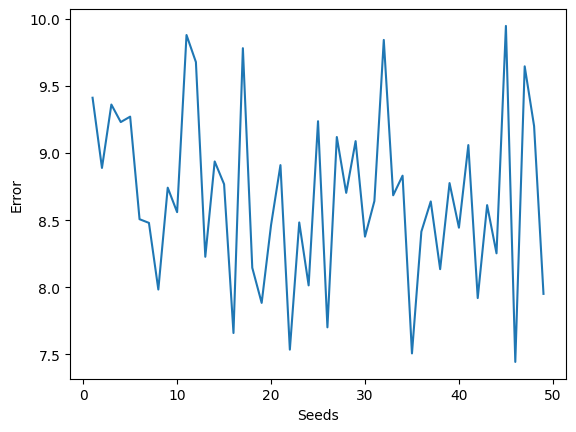

In [7]:
error = []
seeds = range(1,50)
for seed in seeds:
    X_train, X_test, y_train, y_test = train_test_split(X_known, y_known, test_size=0.1, random_state = seed)
    lg.fit(X_train, y_train)
    #making the prediction
    y_pred = lg.predict(X_test)
    error.append(mean_absolute_error(y_test, y_pred))

plt.plot(seeds, error)
plt.xlabel("Seeds")
plt.ylabel("Error")
plt.show()

#### decided to use random_state 38

In [8]:
#split the data using random_state = 2
X_train, X_test, y_train, y_test = train_test_split(X_known, y_known, test_size=0.1, random_state = 46)

lg.fit(X_train, y_train)
#making the prediction
y_pred = lg.predict(X_test)
#testing accuracy by finding mean absolute error, the lower one can get these , the better
MAE = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(rmse)
print(MAE)

9.680495117688254
7.443692515861239


### Using random forest regressor

In [9]:
from sklearn.ensemble import RandomForestRegressor

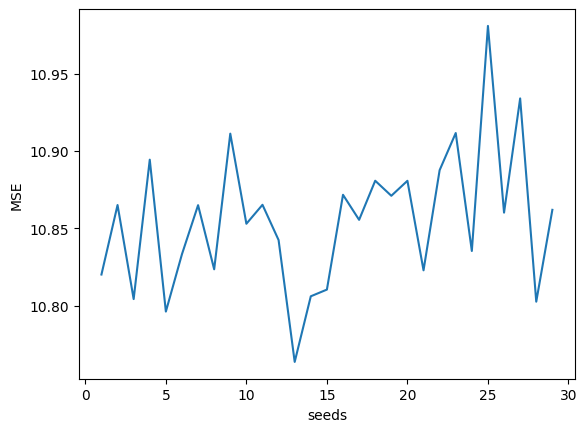

In [10]:
error = []
seeds = range(1,30)
for seed in seeds:
     rfr = RandomForestRegressor(random_state=seed)
     X_train, X_test, y_train, y_test = train_test_split(X_known, y_known, test_size=0.2, random_state = 2)
     rfr.fit(X_train, y_train)
     y_pred = rfr.predict(X_test) 
     error.append(np.sqrt(mean_squared_error(y_test, y_pred)))

plt.plot(seeds, error)
plt.ylabel('MSE')
plt.xlabel('seeds')
plt.show()

In [18]:
rfr = RandomForestRegressor(
    random_state=13
)
X_train, X_test, y_train, y_test = train_test_split(X_known, y_known, test_size=0.2, random_state = 13)
rfr.fit(X_train, y_train)
y_pred = rfr.predict(X_test)
MAE = np.sqrt(mean_squared_error(y_test, y_pred))
MAE

np.float64(10.578066483094485)

### comparing with a naive model

In [12]:
median_age = y_known.median()
baseline_preds = [median_age] * len(y_known)
baseline_rmse = np.sqrt(mean_squared_error(y_known, baseline_preds))
baseline_rmse

np.float64(14.528897166270701)

### use the random linear regression to determine the missing ages since it has low MAE

In [13]:
# predicting missing ages: refit on all rows with known Age (not just the last CV split)
lg.fit(X_known, y_known)
predicted_ages = lg.predict(X_missing)
df.loc[df['Age'].isnull(), 'Age'] = predicted_ages

In [19]:
df.isna().sum()

PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Title          0
Deck           0
TicketFreq     0
dtype: int64

## Export `ready.csv`

This file is the input to `making_submission_file.ipynb` (merge `Survived` from `train.csv`, then train and write `submit.csv`).


In [20]:
# Ticket frequency feature (same idea as in your prior ready1.csv pipeline)
df['TicketFreq'] = df.groupby('Ticket')['Ticket'].transform('count')
out = df.drop(columns=['Ticket'])
out.to_csv('ready.csv', index=False)
print('Wrote ready.csv with shape', out.shape)
out.head()


Wrote ready.csv with shape (1309, 12)


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,Title,Deck,TicketFreq
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S,Mr,U,1
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C,Mrs,C,2
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S,Miss,U,1
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S,Mrs,C,2
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S,Mr,U,1
